In [55]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve,auc, precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

import numpy as np
import pandas as pd
from tensorflow.keras import layers, Model
import tensorflow as tf


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
# Paths
data_dir = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/in-hospital-mortality/train'
label_file = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/in-hospital-mortality/train/listfile.csv'

# Load label file
labels = pd.read_csv(label_file)

# Make a dict: {episode_episode: y_true}
label_dict = dict(zip(labels['stay'], labels['y_true']))

all_dfs = []

# Loop over all episode CSV files
for fname in os.listdir(data_dir):
    if fname.endswith("_timeseries.csv"):
        fpath = os.path.join(data_dir, fname)

        df0 = pd.read_csv(fpath)

        # Add episode name
        df0['episode'] = fname

        # Add y_true from listfile
        df0['y_true'] = label_dict.get(fname)

        all_dfs.append(df0)

# Combine into one DataFrame
df = pd.concat(all_dfs, ignore_index=True)

df.head()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true
0,0.006389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
1,0.023056,NaN,54.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,100.0,12.0,92.0,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
2,0.056389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
3,0.139722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
4,0.323056,NaN,52.0,NaN,NaN,NaN,NaN,NaN,174.0,NaN,NaN,62.0,99.0,NaN,92.0,NaN,NaN,7.4,75188_episode2_timeseries.csv,0


In [3]:
# Paths
data_dir = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/in-hospital-mortality/test'
label_file = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/in-hospital-mortality/test/listfile.csv'

# Load label file
labels = pd.read_csv(label_file)

# Make a dict: {episode_episode: y_true}
label_dict = dict(zip(labels['stay'], labels['y_true']))

all_dfs = []

# Loop over all episode CSV files
for fname in os.listdir(data_dir):
    if fname.endswith("_timeseries.csv"):
        fpath = os.path.join(data_dir, fname)

        df0 = pd.read_csv(fpath)

        # Add episode name
        df0['episode'] = fname

        # Add y_true from listfile
        df0['y_true'] = label_dict.get(fname)

        all_dfs.append(df0)

# Combine into one DataFrame
dft = pd.concat(all_dfs, ignore_index=True)

dft.head()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true
0,0.158333,NaN,69.0,NaN,2 To pain,4 Flex-withdraws,7.0,1.0 ET/Trach,NaN,95.0,NaN,91.0,98.0,4.0,169.0,37.166698,73.5,NaN,17407_episode1_timeseries.csv,0
1,0.658333,NaN,63.0,NaN,NaN,NaN,NaN,NaN,NaN,66.0,NaN,81.0,100.0,NaN,143.0,NaN,NaN,NaN,17407_episode1_timeseries.csv,0
2,1.708333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.38,17407_episode1_timeseries.csv,0
3,4.158333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,17407_episode1_timeseries.csv,0
4,4.408333,NaN,62.0,NaN,2 To pain,5 Localizes Pain,8.0,1.0 ET/Trach,NaN,75.0,NaN,85.0,100.0,16.0,139.0,NaN,NaN,NaN,17407_episode1_timeseries.csv,0


In [4]:
# Create mapping from episode → index string
file_map = {name: str(i) for i, name in enumerate(df['episode'].unique())}

# Replace values
df['episode'] = df['episode'].map(file_map)

In [5]:
# Create mapping from episode → index string
file_map = {name: str(i) for i, name in enumerate(dft['episode'].unique())}

# Replace values
dft['episode'] = dft['episode'].map(file_map)

In [6]:
#Find the number of missing values in each column
missing_values = df.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(df)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Capillary refill rate,1455000,99.791090
Height,1454657,99.767566
Weight,1427176,97.882783
Fraction inspired oxygen,1376659,94.418077
pH,1335179,91.573174
Glascow coma scale total,1299168,89.103362
Glucose,1210442,83.018094
Glascow coma scale eye opening,1205498,82.679010
Glascow coma scale motor response,1189425,81.576644
Glascow coma scale verbal response,1189172,81.559292


In [7]:
gcs_motor_map = {
    # 6
    '6 Obeys Commands': 6,
    'Obeys Commands': 6,

    # 5
    '5 Localizes Pain': 5,
    'Localizes Pain': 5,

    # 4
    '4 Flex-withdraws': 4,
    'Flex-withdraws': 4,

    # 3
    '3 Abnorm flexion': 3,
    'Abnormal Flexion': 3,

    # 2
    '2 Abnorm extensn': 2,
    'Abnormal extension': 2,

    # 1
    '1 No Response': 1,
    'No response': 1
}


gcs_eye_map = {
    # 4
    '4 Spontaneously': 4,
    'Spontaneously': 4,

    # 3
    '3 To speech': 3,
    'To Speech': 3,

    # 2
    '2 To pain': 2,
    'To Pain': 2,

    # 1
    '1 No Response': 1
}


gcs_verbal_map = {
    # Score 5
    'Oriented': 5,
    '5 Oriented': 5,

    # Score 4
    'Confused': 4,
    '4 Confused': 4,

    # Score 3
    'Inappropriate Words': 3,
    '3 Inapprop words': 3,

    # Score 2
    'Incomprehensible sounds': 2,
    '2 Incomp sounds': 2,

    # Score 1
    'No Response': 1,
    '1 No Response': 1,
    'No Response-ETT': 1,
    '1.0 ET/Trach': 1
}



df['Glascow coma scale motor response'] = (
    df['Glascow coma scale motor response']
    .replace(gcs_motor_map)
)


df['Glascow coma scale eye opening'] = (
    df['Glascow coma scale eye opening']
    .replace(gcs_eye_map)
)

df['Glascow coma scale verbal response'] = (
    df['Glascow coma scale verbal response']
    .replace(gcs_verbal_map)
)



/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_2012/613039223.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_motor_map)
/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_2012/613039223.py:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_eye_map)
/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_2012/613039223.py:85: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result

In [8]:
gcs_motor_map = {
    # 6
    '6 Obeys Commands': 6,
    'Obeys Commands': 6,

    # 5
    '5 Localizes Pain': 5,
    'Localizes Pain': 5,

    # 4
    '4 Flex-withdraws': 4,
    'Flex-withdraws': 4,

    # 3
    '3 Abnorm flexion': 3,
    'Abnormal Flexion': 3,

    # 2
    '2 Abnorm extensn': 2,
    'Abnormal extension': 2,

    # 1
    '1 No Response': 1,
    'No response': 1
}


gcs_eye_map = {
    # 4
    '4 Spontaneously': 4,
    'Spontaneously': 4,

    # 3
    '3 To speech': 3,
    'To Speech': 3,

    # 2
    '2 To pain': 2,
    'To Pain': 2,

    # 1
    '1 No Response': 1
}


gcs_verbal_map = {
    # Score 5
    'Oriented': 5,
    '5 Oriented': 5,

    # Score 4
    'Confused': 4,
    '4 Confused': 4,

    # Score 3
    'Inappropriate Words': 3,
    '3 Inapprop words': 3,

    # Score 2
    'Incomprehensible sounds': 2,
    '2 Incomp sounds': 2,

    # Score 1
    'No Response': 1,
    '1 No Response': 1,
    'No Response-ETT': 1,
    '1.0 ET/Trach': 1
}



dft['Glascow coma scale motor response'] = (
    dft['Glascow coma scale motor response']
    .replace(gcs_motor_map)
)


dft['Glascow coma scale eye opening'] = (
    dft['Glascow coma scale eye opening']
    .replace(gcs_eye_map)
)

dft['Glascow coma scale verbal response'] = (
    dft['Glascow coma scale verbal response']
    .replace(gcs_verbal_map)
)



/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_2012/3611392735.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_motor_map)
/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_2012/3611392735.py:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_eye_map)
/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_2012/3611392735.py:85: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `res

In [9]:
df['Glascow coma scale motor response'].value_counts()

Glascow coma scale motor response
6.0    187807
5.0     36420
4.0     20364
1.0     19923
3.0      2064
2.0      2043
Name: count, dtype: int64

In [10]:
df['Glascow coma scale eye opening'].value_counts()

Glascow coma scale eye opening
4.0    154096
3.0     53715
1.0     27328
2.0     17409
Name: count, dtype: int64

In [11]:
df['Glascow coma scale verbal response'].value_counts()

Glascow coma scale verbal response
5.0    125414
1.0    111200
4.0     24295
2.0      5779
3.0      2186
Name: count, dtype: int64

In [12]:
df['Glascow coma scale verbal response'].value_counts()

Glascow coma scale verbal response
5.0    125414
1.0    111200
4.0     24295
2.0      5779
3.0      2186
Name: count, dtype: int64

In [13]:
df['Glascow total'] = df['Glascow coma scale verbal response']+df['Glascow coma scale eye opening']+df['Glascow coma scale motor response']

In [14]:
dft['Glascow total'] = dft['Glascow coma scale verbal response']+dft['Glascow coma scale eye opening']+dft['Glascow coma scale motor response']

In [15]:
#Find the number of missing values in each column
missing_values = df.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(df)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Capillary refill rate,1455000,99.791090
Height,1454657,99.767566
Weight,1427176,97.882783
Fraction inspired oxygen,1376659,94.418077
pH,1335179,91.573174
Glascow coma scale total,1299168,89.103362
Glucose,1210442,83.018094
Glascow total,1207990,82.849924
Glascow coma scale eye opening,1205498,82.679010
Glascow coma scale motor response,1189425,81.576644


In [16]:
normal_values = {
    "Capillary refill rate": 0.0,
    "Diastolic blood pressure": 59.0,
    "Fraction inspired oxygen": 0.21,
    "Glascow coma scale eye opening": 4.0,
    "Glascow coma scale motor response": 6.0,
    "Glascow coma scale total": 15,
    "Glascow coma scale verbal response": 5.0,
    "Glucose": 128.0,
    "Heart Rate": 86,
    "Height": 170.0,
    "Mean blood pressure": 77.0,
    "Oxygen saturation": 98.0,
    "Respiratory rate": 19,
    "Systolic blood pressure": 118.0,
    "Temperature": 36.6,
    "Weight": 81.0,
    "pH": 7.4,
    "Glascow total": 15,
}

for col, val in normal_values.items():
    if col in df.columns:

        df[col] = (
            df.groupby('episode')[col]
              .transform(lambda x: x.ffill().bfill())
        )

        df[col] = df[col].fillna(val)

In [17]:
normal_values = {
    "Capillary refill rate": 0.0,
    "Diastolic blood pressure": 59.0,
    "Fraction inspired oxygen": 0.21,
    "Glascow coma scale eye opening": 4.0,
    "Glascow coma scale motor response": 6.0,
    "Glascow coma scale total": 15,
    "Glascow coma scale verbal response": 5.0,
    "Glucose": 128.0,
    "Heart Rate": 86,
    "Height": 170.0,
    "Mean blood pressure": 77.0,
    "Oxygen saturation": 98.0,
    "Respiratory rate": 19,
    "Systolic blood pressure": 118.0,
    "Temperature": 36.6,
    "Weight": 81.0,
    "pH": 7.4,
    "Glascow total": 15,
}

for col, val in normal_values.items():
    if col in dft.columns:

        dft[col] = (
            dft.groupby('episode')[col]
              .transform(lambda x: x.ffill().bfill())
        )

        dft[col] = dft[col].fillna(val)

In [18]:
#Find the number of missing values in each column
missing_values = df.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(df)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Hours,0,0.0
Mean blood pressure,0,0.0
y_true,0,0.0
episode,0,0.0
pH,0,0.0
Weight,0,0.0
Temperature,0,0.0
Systolic blood pressure,0,0.0
Respiratory rate,0,0.0
Oxygen saturation,0,0.0


In [19]:
#Find the number of missing values in each column
missing_values = dft.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(dft)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Hours,0,0.0
Mean blood pressure,0,0.0
y_true,0,0.0
episode,0,0.0
pH,0,0.0
Weight,0,0.0
Temperature,0,0.0
Systolic blood pressure,0,0.0
Respiratory rate,0,0.0
Oxygen saturation,0,0.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458046 entries, 0 to 1458045
Data columns (total 21 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   Hours                               1458046 non-null  float64
 1   Capillary refill rate               1458046 non-null  float64
 2   Diastolic blood pressure            1458046 non-null  float64
 3   Fraction inspired oxygen            1458046 non-null  float64
 4   Glascow coma scale eye opening      1458046 non-null  float64
 5   Glascow coma scale motor response   1458046 non-null  float64
 6   Glascow coma scale total            1458046 non-null  float64
 7   Glascow coma scale verbal response  1458046 non-null  float64
 8   Glucose                             1458046 non-null  float64
 9   Heart Rate                          1458046 non-null  float64
 10  Height                              1458046 non-null  float64
 11  Mean blood 

In [21]:
df.head()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
0,0.006389,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,8.0,92.0,35.388889,75.8,7.4,0,0,10.0
1,0.023056,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0
2,0.056389,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0
3,0.139722,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0
4,0.323056,0.0,52.0,1.0,3.0,6.0,15.0,1.0,174.0,152.0,183.0,62.0,99.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0


In [22]:
df_median = df.groupby('episode').median().reset_index()

In [23]:
dft_median = dft.groupby('episode').median().reset_index()

In [24]:
df_median.sample(5)

,episode,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,y_true,Glascow total
11576,4303,24.565278,0.0,49.0,0.60,4.0,1.0,15.0,1.0,177.0,76.0,170.0,69.000000,97.0,28.0,107.0,32.800000,71.400000,7.34,1.0,15.0
5654,15086,18.238889,0.0,50.0,1.00,3.0,6.0,15.0,4.0,251.0,80.0,170.0,75.000000,100.0,22.5,118.0,36.500000,60.000000,7.42,0.0,13.0
11722,4435,11.430556,0.0,55.0,0.21,4.0,6.0,10.0,1.0,103.0,88.0,170.0,78.000000,98.0,20.0,124.0,36.799999,73.800003,7.42,0.0,10.0
5184,14663,22.015556,0.0,77.0,0.21,3.0,6.0,11.0,1.0,148.0,94.0,170.0,95.666702,99.0,18.0,125.5,36.888901,48.000000,7.44,0.0,11.0
8471,17621,17.451389,0.0,64.0,0.35,4.0,6.0,15.0,5.0,120.0,80.0,170.0,75.000000,99.0,14.0,103.0,37.000000,77.100000,7.33,0.0,15.0


In [25]:
y = df_median['y_true']
X = df_median.drop(columns=['episode','y_true','Hours']) 

In [26]:
yt = dft_median['y_true']
Xt = dft_median.drop(columns=['episode','y_true','Hours']) 

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17903 entries, 0 to 17902
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Capillary refill rate               17903 non-null  float64
 1   Diastolic blood pressure            17903 non-null  float64
 2   Fraction inspired oxygen            17903 non-null  float64
 3   Glascow coma scale eye opening      17903 non-null  float64
 4   Glascow coma scale motor response   17903 non-null  float64
 5   Glascow coma scale total            17903 non-null  float64
 6   Glascow coma scale verbal response  17903 non-null  float64
 7   Glucose                             17903 non-null  float64
 8   Heart Rate                          17903 non-null  float64
 9   Height                              17903 non-null  float64
 10  Mean blood pressure                 17903 non-null  float64
 11  Oxygen saturation                   17903

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify = y)

# Log Reg

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [30]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

from sklearn.metrics import average_precision_score

auc_pr = average_precision_score(y_test, y_prob)
print("AUC-PR:", auc_pr)

AUC-ROC: 0.758318681904153
AUC-PR: 0.34146256600884206


In [31]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    solver='lbfgs'
)

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score

clf.fit(X_train, y_train)
y_pred_prob = clf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc  = average_precision_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.7521677455446336
PR-AUC: 0.33639534559092676


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # let trees expand fully
    min_samples_split=5,     # avoid overfitting
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight='balanced', # important for mortality (~10% positive)
    random_state=42
)

clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [34]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_prob = clf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc  = average_precision_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.801165787580916
PR-AUC: 0.42830793473087486


# XGBoost

In [35]:
y.value_counts()

y_true
0.0    15480
1.0     2423
Name: count, dtype: int64

In [36]:
2423/15480

0.15652454780361758

In [37]:
import xgboost as xgb

clf = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.6,
    eval_metric='auc',
    tree_method='hist',        # or 'gpu_hist' if GPU available
    nthread=4,
    scale_pos_weight=0.156,        # adjust for mortality imbalance
    early_stopping_rounds=10
)

h = clf.fit(X_train, y_train, 
    eval_set=[(X_test,y_test)],
    verbose=50)

[0]	validation_0-auc:0.73225


[50]	validation_0-auc:0.78407
[100]	validation_0-auc:0.79116
[150]	validation_0-auc:0.79745
[200]	validation_0-auc:0.80148
[250]	validation_0-auc:0.80600
[300]	validation_0-auc:0.80857
[350]	validation_0-auc:0.81019
[372]	validation_0-auc:0.81040


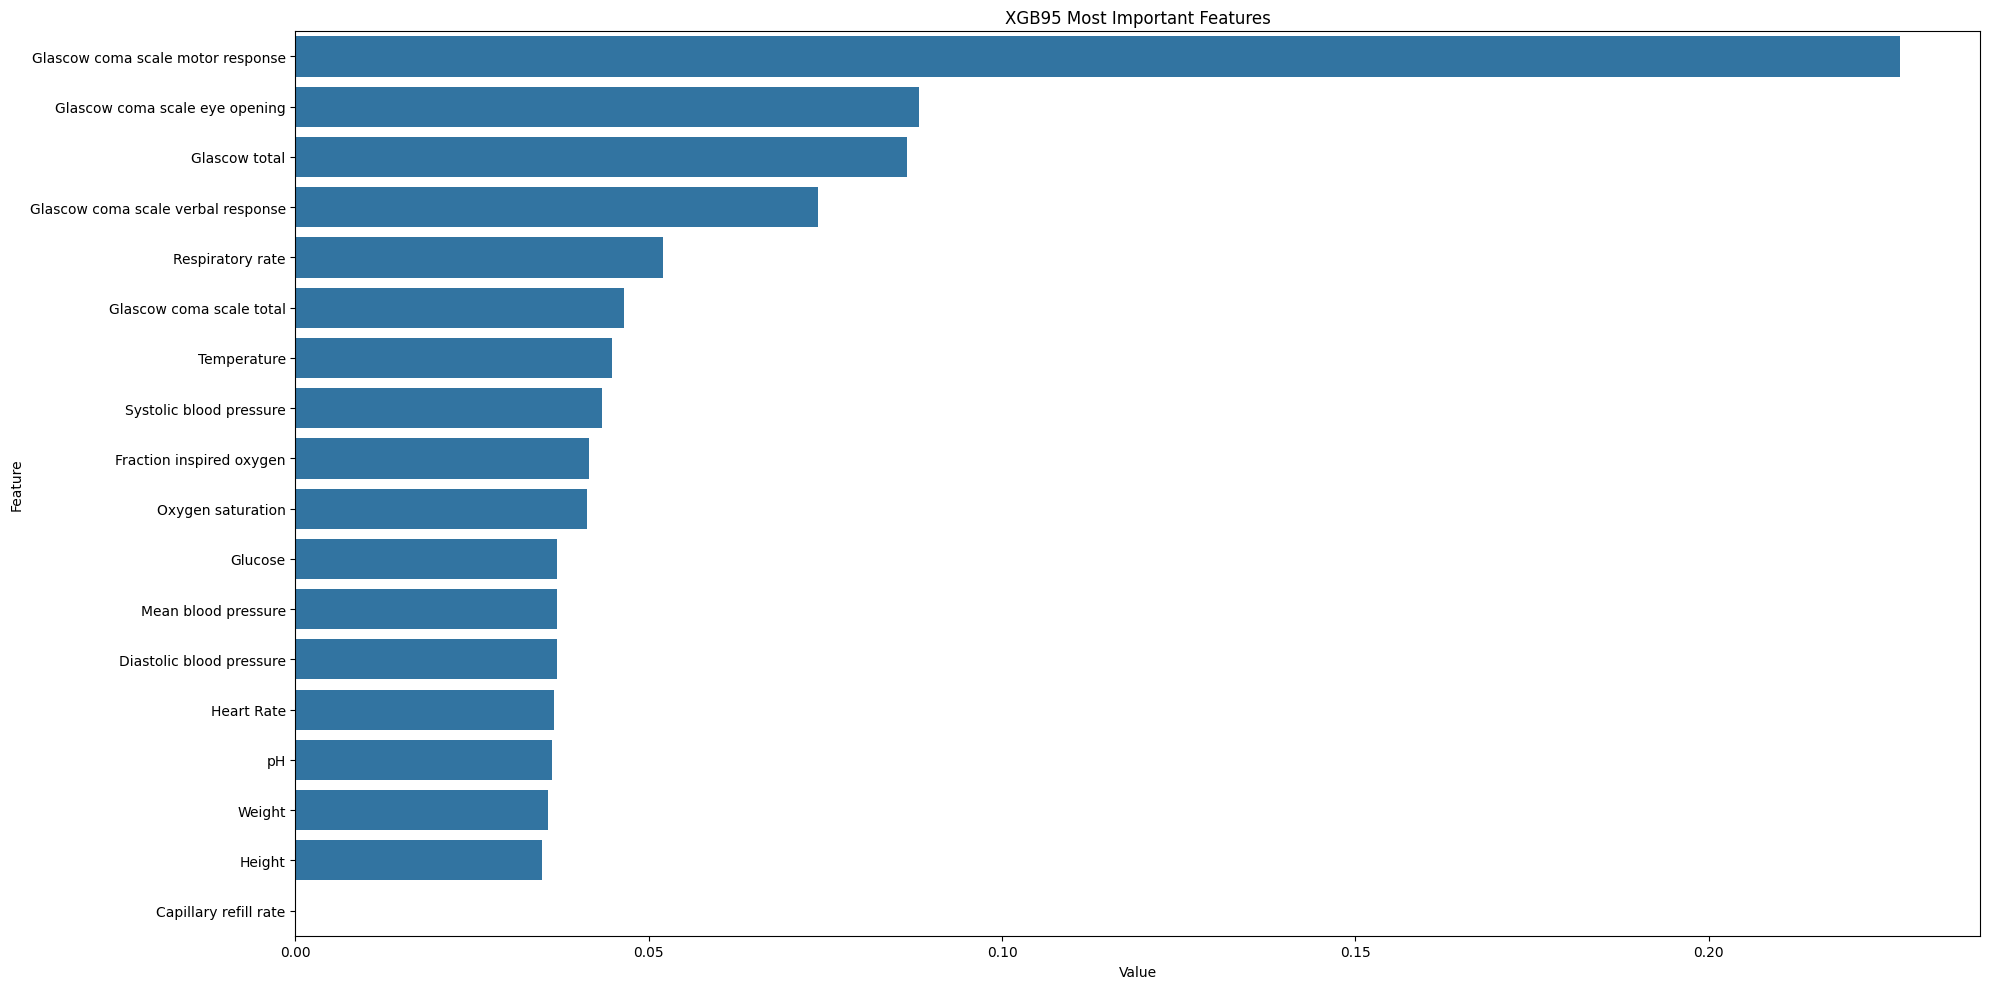

In [38]:
cols = X.columns.to_list()
feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
plt.figure(figsize=(20, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
plt.title('XGB95 Most Important Features')
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_prob = clf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)



ROC-AUC: 0.8106239510908655
PR-AUC: 0.44704378503510667


# Test Data

In [40]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_prob = clf.predict_proba(Xt)[:, 1]
roc_auc = roc_auc_score(yt, y_pred_prob)
pr_auc = average_precision_score(yt, y_pred_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.8262321700168538
PR-AUC: 0.4142225533016975


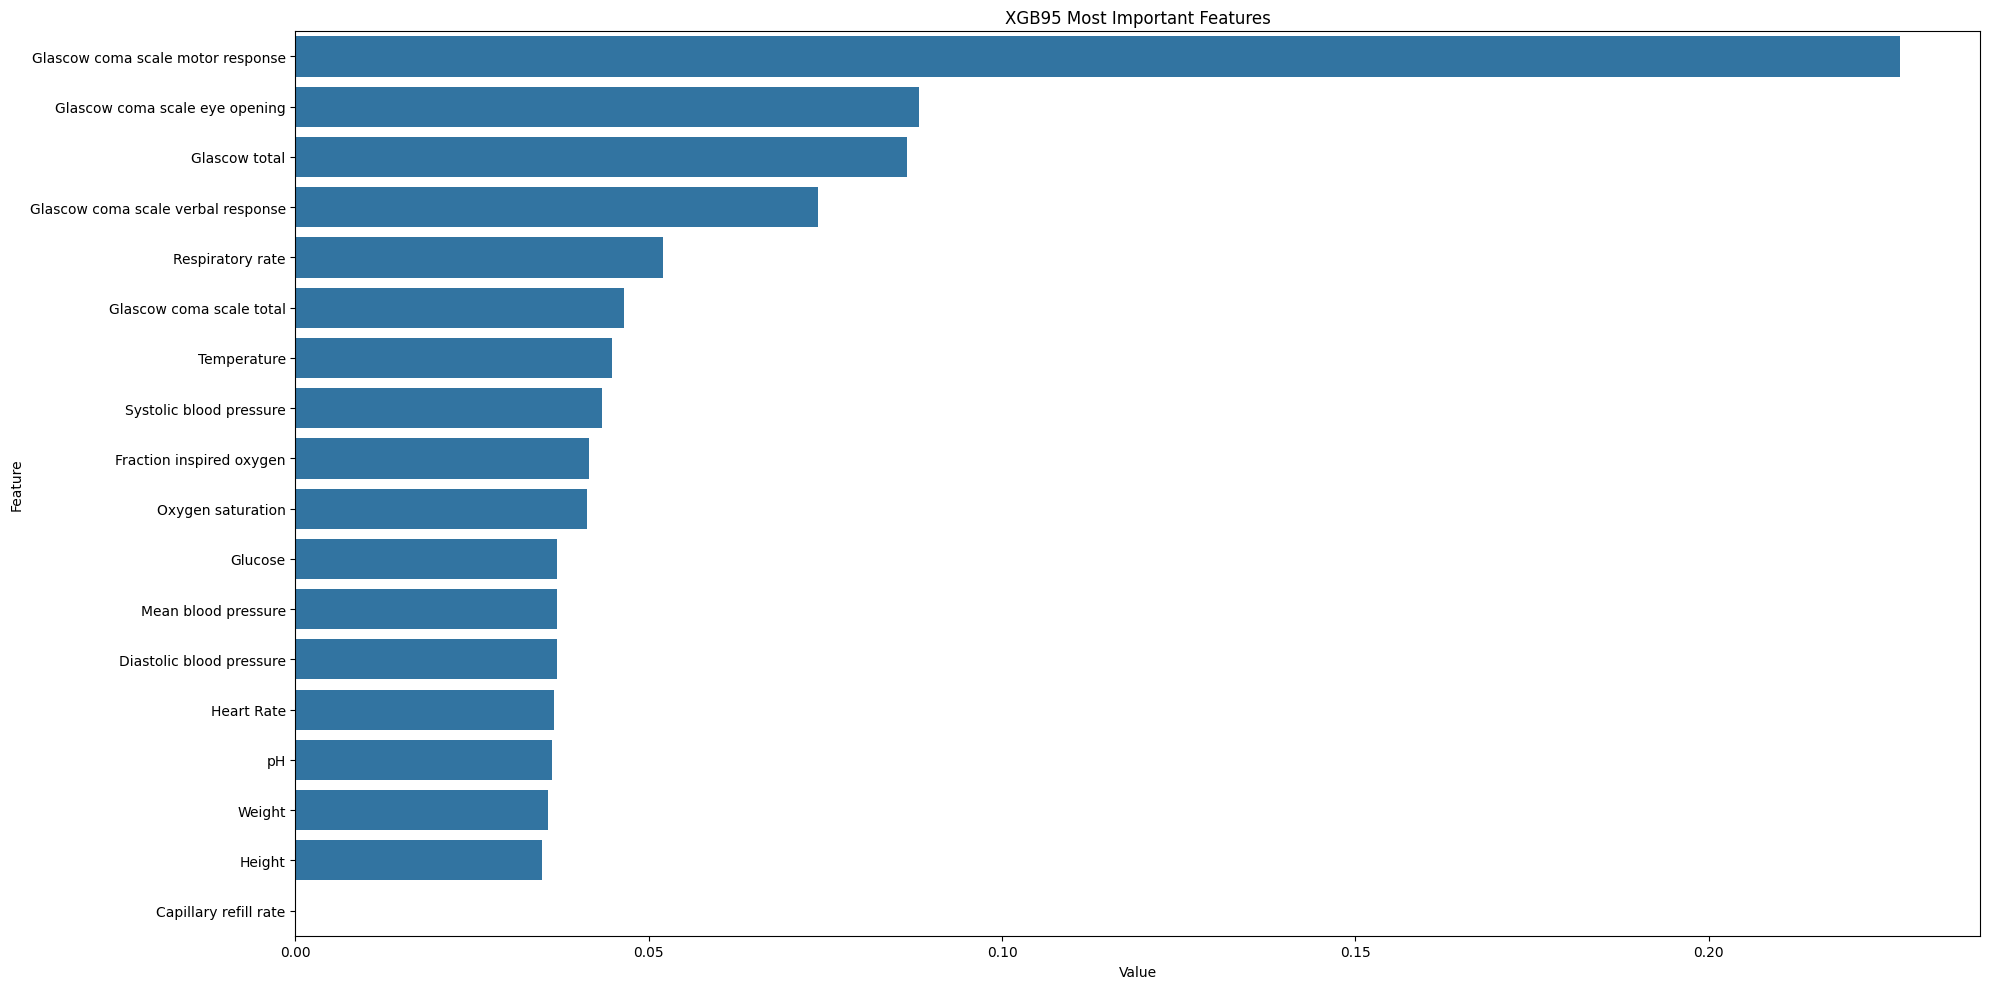

In [41]:
cols = Xt.columns.to_list()
feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
plt.figure(figsize=(20, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
plt.title('XGB95 Most Important Features')
plt.tight_layout()
plt.show()

In [42]:
df_median.head()

,episode,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,y_true,Glascow total
0,0,21.581389,0.0,66.5,0.40,3.0,6.0,15.0,1.0,147.0,89.0,183.0,80.000000,100.0,14.0,121.5,37.000000,80.000000,7.42,0.0,10.0
1,1,24.707500,0.0,85.0,0.21,4.0,6.0,15.0,5.0,250.0,88.0,170.0,98.000000,98.0,19.0,138.0,36.944444,65.000000,7.30,0.0,15.0
2,10,21.570000,0.0,72.5,0.21,4.0,6.0,15.0,4.0,105.0,93.0,170.0,80.500000,98.5,21.0,107.0,37.111111,84.232034,6.00,0.0,14.0
3,100,21.547222,0.0,66.5,0.21,4.0,6.0,15.0,5.0,70.0,104.5,170.0,79.666702,94.0,28.0,95.5,36.388901,81.000000,7.40,1.0,15.0
4,1000,18.586944,0.0,59.5,0.40,4.0,6.0,15.0,4.0,108.0,62.5,170.0,77.500000,98.0,16.0,107.0,37.333333,89.811216,7.43,0.0,14.0


In [43]:
df_median.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17903 entries, 0 to 17902
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   episode                             17903 non-null  object 
 1   Hours                               17903 non-null  float64
 2   Capillary refill rate               17903 non-null  float64
 3   Diastolic blood pressure            17903 non-null  float64
 4   Fraction inspired oxygen            17903 non-null  float64
 5   Glascow coma scale eye opening      17903 non-null  float64
 6   Glascow coma scale motor response   17903 non-null  float64
 7   Glascow coma scale total            17903 non-null  float64
 8   Glascow coma scale verbal response  17903 non-null  float64
 9   Glucose                             17903 non-null  float64
 10  Heart Rate                          17903 non-null  float64
 11  Height                              17903

In [44]:
df_text = pd.DataFrame()

In [45]:
df_text.head()

""


In [46]:
text_data = []
for i, row in df_median.iterrows():
    text = (
        #f"Episode {row['episode']}: "
        f"Median Values of patient ICU data for first 48 hours: "
        f"Capillary refill rate is {row['Capillary refill rate']}, "
        f"Diastolic blood pressure is {row['Diastolic blood pressure']}, "
        f"Fraction inspired oxygen is {row['Fraction inspired oxygen']}, "
        f"Glasgow eye opening {row['Glascow coma scale eye opening']}, "
        f"Glasgow motor response {row['Glascow coma scale motor response']}, "
        #f"Glasgow coma scale total {row['Glascow coma scale total']}, "
        f"Glasgow verbal response {row['Glascow coma scale verbal response']}, "
        f"Glasgow total {row['Glascow total']}, "
        f"Glucose {row['Glucose']}, "
        f"Heart rate {row['Heart Rate']}, "
        f"Height {row['Height']}, "
        f"Hours {row['Hours']}, "
        f"Mean blood pressure {row['Mean blood pressure']}, "
        f"Oxygen saturation {row['Oxygen saturation']}, "
        f"Respiratory rate {row['Respiratory rate']}, "
        f"Systolic blood pressure {row['Systolic blood pressure']}, "
        f"Temperature {row['Temperature']}, "
        f"Weight {row['Weight']}, "
        f"pH {row['pH']}."
    )
    text_data.append(text)
df_text['text'] = text_data

In [47]:
df_text['y_true'] = df_median['y_true']

In [48]:
df_text.iloc[1,0]

'Median Values of patient ICU data for first 48 hours: Capillary refill rate is 0.0, Diastolic blood pressure is 85.0, Fraction inspired oxygen is 0.21, Glasgow eye opening 4.0, Glasgow motor response 6.0, Glasgow verbal response 5.0, Glasgow total 15.0, Glucose 250.0, Heart rate 88.0, Height 170.0, Hours 24.7075, Mean blood pressure 98.0, Oxygen saturation 98.0, Respiratory rate 19.0, Systolic blood pressure 138.0, Temperature 36.94444444444444, Weight 65.0, pH 7.3.'

In [49]:
df_text.head()

,text,y_true
0,Median Values of patient ICU data for first 48...,0.0
1,Median Values of patient ICU data for first 48...,0.0
2,Median Values of patient ICU data for first 48...,0.0
3,Median Values of patient ICU data for first 48...,1.0
4,Median Values of patient ICU data for first 48...,0.0


In [50]:
OUTPUT_FILE = "/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mort_text.csv"

df_text.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)

Saved: /Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mort_text.csv


In [51]:
df.head()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
0,0.006389,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,8.0,92.0,35.388889,75.8,7.4,0,0,10.0
1,0.023056,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0
2,0.056389,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0
3,0.139722,0.0,54.0,1.0,3.0,6.0,15.0,1.0,179.0,152.0,183.0,70.0,100.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0
4,0.323056,0.0,52.0,1.0,3.0,6.0,15.0,1.0,174.0,152.0,183.0,62.0,99.0,12.0,92.0,35.388889,75.8,7.4,0,0,10.0


In [52]:
df.columns

Index(['Hours', 'Capillary refill rate', 'Diastolic blood pressure',
       'Fraction inspired oxygen', 'Glascow coma scale eye opening',
       'Glascow coma scale motor response', 'Glascow coma scale total',
       'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
       'Mean blood pressure', 'Oxygen saturation', 'Respiratory rate',
       'Systolic blood pressure', 'Temperature', 'Weight', 'pH', 'episode',
       'y_true', 'Glascow total'],
      dtype='object')

# LSTM

In [53]:
# Check the distribution of episode lengths
counts = df.groupby('episode').size()
print(counts.value_counts().sort_index())
print(f"\nMin: {counts.min()}, Max: {counts.max()}, Episodes total: {len(counts)}")

1         1
2        14
3        16
4        12
5        18
6        15
7        11
8         6
9        12
10        8
11        9
12        8
13        3
14        7
15        8
16        3
17       10
18        4
19        4
20        4
21        5
22        3
23        4
24        7
25        6
26        7
27        3
28        8
29        7
30        4
31        9
32       10
33       16
34        8
35       18
36       19
37       24
38       20
39       27
40       27
41       36
42       39
43       41
44       50
45       68
46       83
47      109
48      126
49      155
50      161
51      218
52      236
53      268
54      269
55      259
56      259
57      269
58      306
59      291
60      264
61      295
62      284
63      287
64      307
65      317
66      310
67      315
68      346
69      349
70      361
71      349
72      354
73      344
74      366
75      356
76      338
77      381
78      356
79      344
80      311
81      351
82      340
83      291
84  

In [56]:
def build_lstm(timesteps=48, features=17):
    inp = tf.keras.Input(shape=(timesteps, features))
    x = layers.Masking(mask_value=0.0)(inp)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inp, out)

model = build_lstm(timesteps=48, features=F)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 48, 17)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 48, 17)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 48)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 48, 64)    │     20,992 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
feature_cols = [
    'Capillary refill rate', 'Diastolic blood pressure', 'Fraction inspired oxygen',
    'Glascow coma scale eye opening', 'Glascow coma scale motor response',
    'Glascow coma scale total', 'Glascow coma scale verbal response',
    'Glucose', 'Heart Rate', 'Height', 'Mean blood pressure',
    'Oxygen saturation', 'Respiratory rate', 'Systolic blood pressure',
    'Temperature', 'Weight', 'pH'
]


T, F = 48, len(feature_cols)

df = df.sort_values(['episode', 'Hours'])
grouped = df.groupby('episode', sort=False)

# Check lengths first
counts = df.groupby('episode').size()
print(f"Min: {counts.min()}, Max: {counts.max()}, Episodes: {len(counts)}")

# Pad/truncate each episode to exactly 48 timesteps
def pad_episode(g):
    arr = g[feature_cols].values
    pad = T - len(arr)
    if pad > 0:
        arr = np.vstack([arr, np.zeros((pad, F))])
    return arr[:T]

# Use pad_episode instead of plain .values
X = np.stack([pad_episode(g) for _, g in grouped])
y = grouped['y_true'].first().values

print(f"X shape: {X.shape}")   # should be (n_episodes, 48, 17)
print(f"y shape: {y.shape}")

Min: 1, Max: 2878, Episodes: 17903
X shape: (17903, 48, 17)
y shape: (17903,)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape to 2D, scale, reshape back
n_train, T, F = X_train.shape
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, F)).reshape(n_train, T, F)
X_test  = scaler.transform(X_test.reshape(-1, F)).reshape(-1, T, F)

In [59]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {0: weights[0], 1: weights[1]}

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auroc')]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auroc', patience=10,
                                      mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - auroc: 0.7224 - loss: 0.6133 - val_auroc: 0.7621 - val_loss: 0.6129 - learning_rate: 0.0010
Epoch 2/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - auroc: 0.7639 - loss: 0.5809 - val_auroc: 0.7870 - val_loss: 0.5029 - learning_rate: 0.0010
Epoch 3/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - auroc: 0.7818 - loss: 0.5612 - val_auroc: 0.7815 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 4/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - auroc: 0.7909 - loss: 0.5520 - val_auroc: 0.7966 - val_loss: 0.5338 - learning_rate: 0.0010
Epoch 5/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - auroc: 0.8008 - loss: 0.5414 - val_auroc: 0.7930 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 6/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - auroc: 0.8091 - loss: 0.5327 - val_auroc: 0.7990 - val_loss: 0.5221 - learning_rate: 0.0010
Epoch 7/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - auroc: 0.8157 - loss: 0.5250 - val_auroc: 0.7887 - val_

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

y_pred = model.predict(X_test).flatten()

print(f"AUROC:       {roc_auc_score(y_test, y_pred):.4f}")
print(f"AUPRC:       {average_precision_score(y_test, y_pred):.4f}")
print(f"Brier score: {brier_score_loss(y_test, y_pred):.4f}")

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
AUROC:       0.7775
AUPRC:       0.3715
Brier score: 0.1873
